# Gaussian OOD plots: MMD, S=D

This notebook is plotting-only. It loads cached posterior, log marginal-likelihood, indirect-PMP, and direct-PMP results; no network inference or diagnostic fitting is performed.

In [7]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "benchmark").is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from benchmark.examples.gaussian.config import RESULT_DIR
from benchmark.examples.gaussian.analysis.pipeline import (
    generate_calibrated_plots,
    load_cached_metric_frames,
)
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd


In [8]:
NETWORK_TAG = "20d_10n"
METRIC = "mmd"
NORMALIZE_METRICS = True  # Applies to posterior MMD/logML only; PMP always remains raw.
YSCALE = {"posterior_mmd": "symlog", "logml": "symlog", "pmp": "linear"}
LOGML_Y_LINTHRESH = 0.01
PMP_Y_LINTHRESH = 0.01
RESULT_ROOT = RESULT_DIR / f"ood_{NETWORK_TAG}"
FIGURE_DIR = RESULT_ROOT / "diagnostics" / METRIC / "figures"

frames = load_cached_metric_frames(RESULT_ROOT, METRIC)
posterior_df = frames["posterior"]
logml_df = frames["logml"]
pmp_df = frames["pmp"]

print({name: frame.shape for name, frame in frames.items()})

generate_calibrated_plots(
    FIGURE_DIR.parent,
    normalize_metrics=NORMALIZE_METRICS,
    yscale=YSCALE,
    frames=frames,
)


{'posterior': (2400, 23), 'logml': (2400, 27), 'pmp': (600, 71)}
Saved calibrated figures: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/ood_20d_10n/diagnostics/mmd/figures


## Posterior


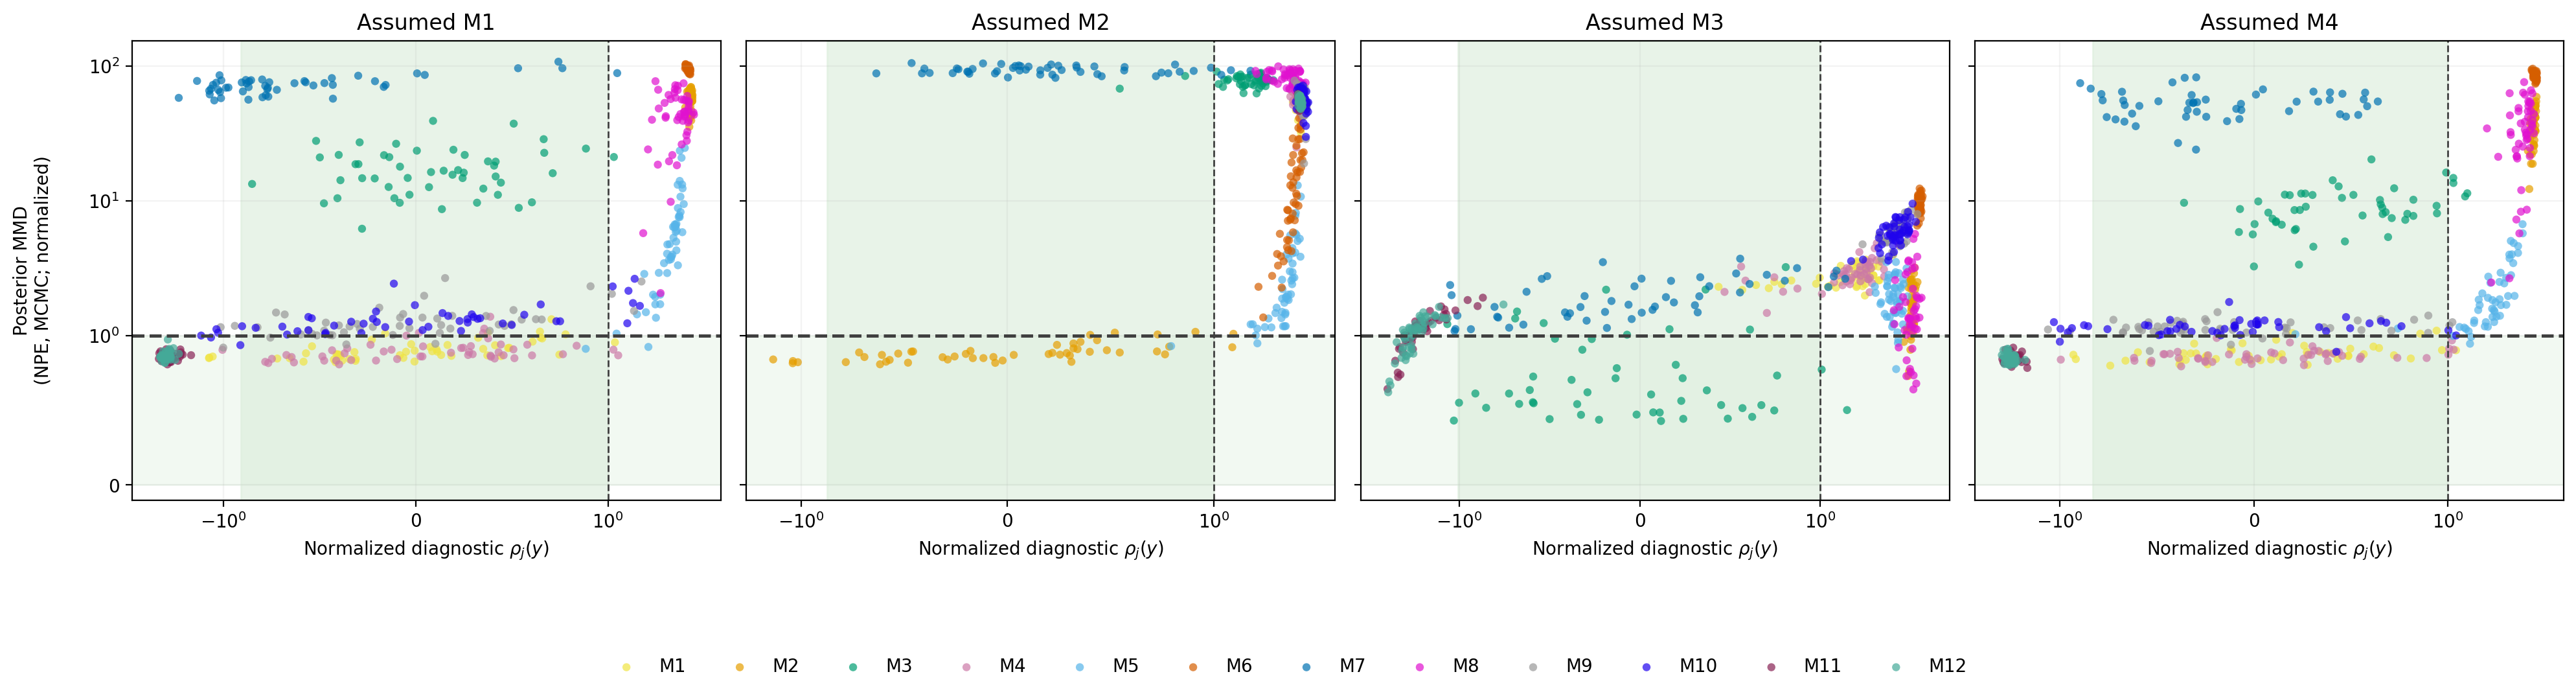

In [9]:
from IPython.display import Image, display

display(
    Image(filename=str(FIGURE_DIR / "posterior_mmd_vs_rho_calibrated.png"))
)


## Log marginal likelihood


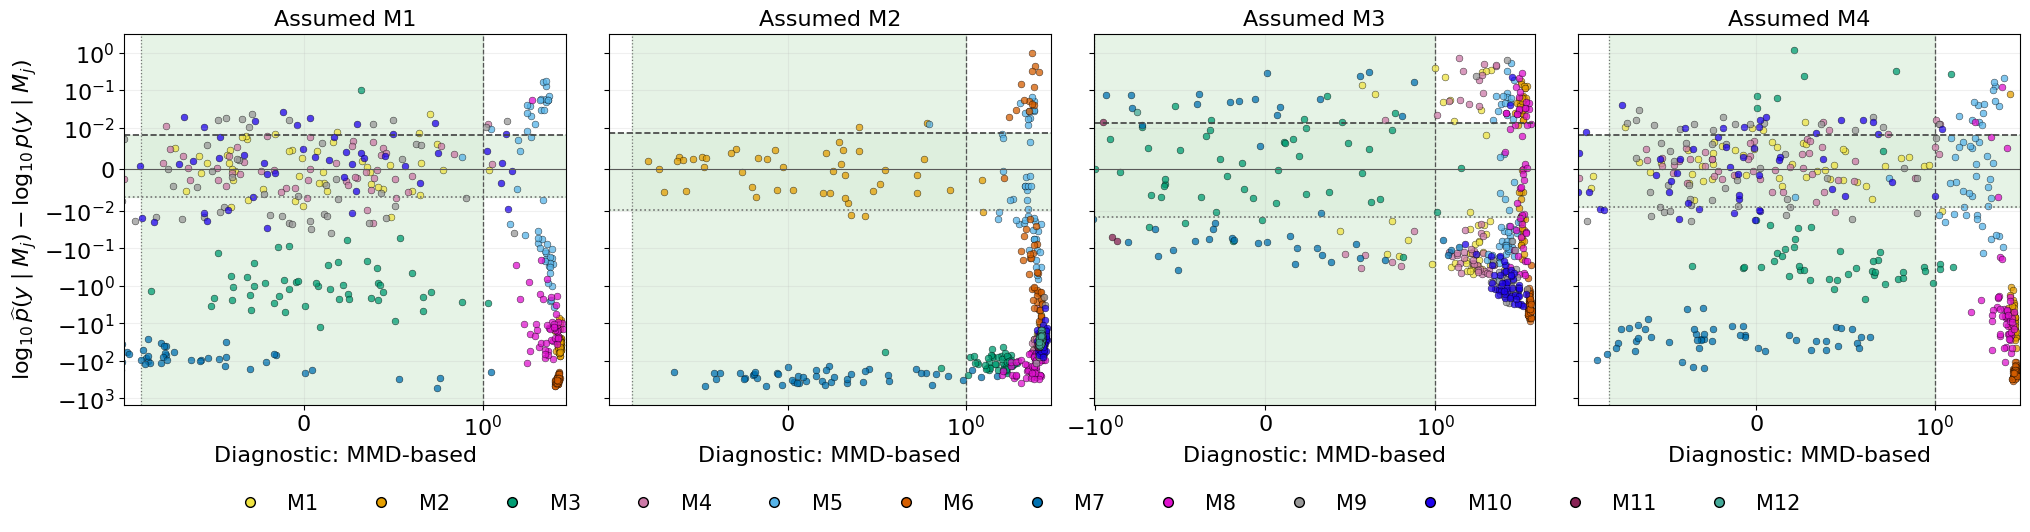

In [10]:
sd.plot_logml_error_vs_distance(
    logml_df,
    color_by="source",
    output_dir=FIGURE_DIR,
    x="rho",
    x_min=-1.0,
    distance_metric=METRIC,
    xscale="symlog",
    yscale=YSCALE["logml"],
    y_linthresh=LOGML_Y_LINTHRESH,
);


## Posterior model probabilities


### Indirect PMP from NPE logML


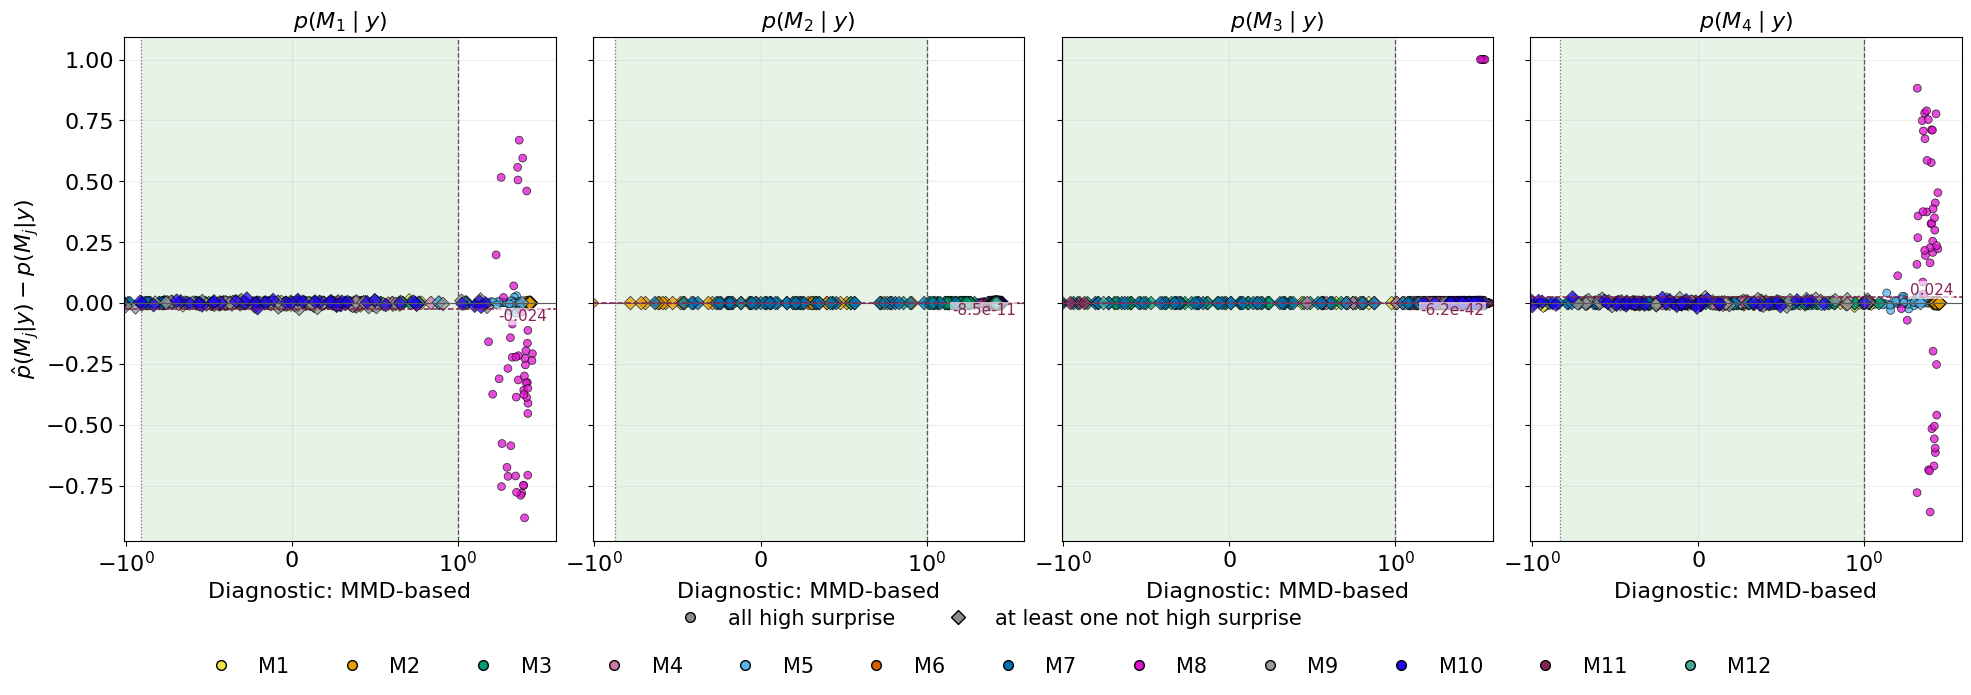

In [11]:
sd.plot_pmp_diagnostic(
    pmp_df,
    x="rho",
    y="signed_error",
    group_by="global_extrapolation_source",
    estimate="npe",
    output_dir=FIGURE_DIR,
    filename="pmp_error_npe_vs_rho.png",
    regions="assumed",
    sharex=True,
    x_min=-1.0,
    distance_metric=METRIC,
    xscale="symlog",
    yscale=YSCALE["pmp"],
    y_linthresh=PMP_Y_LINTHRESH,
);


### Direct model-classifier PMP


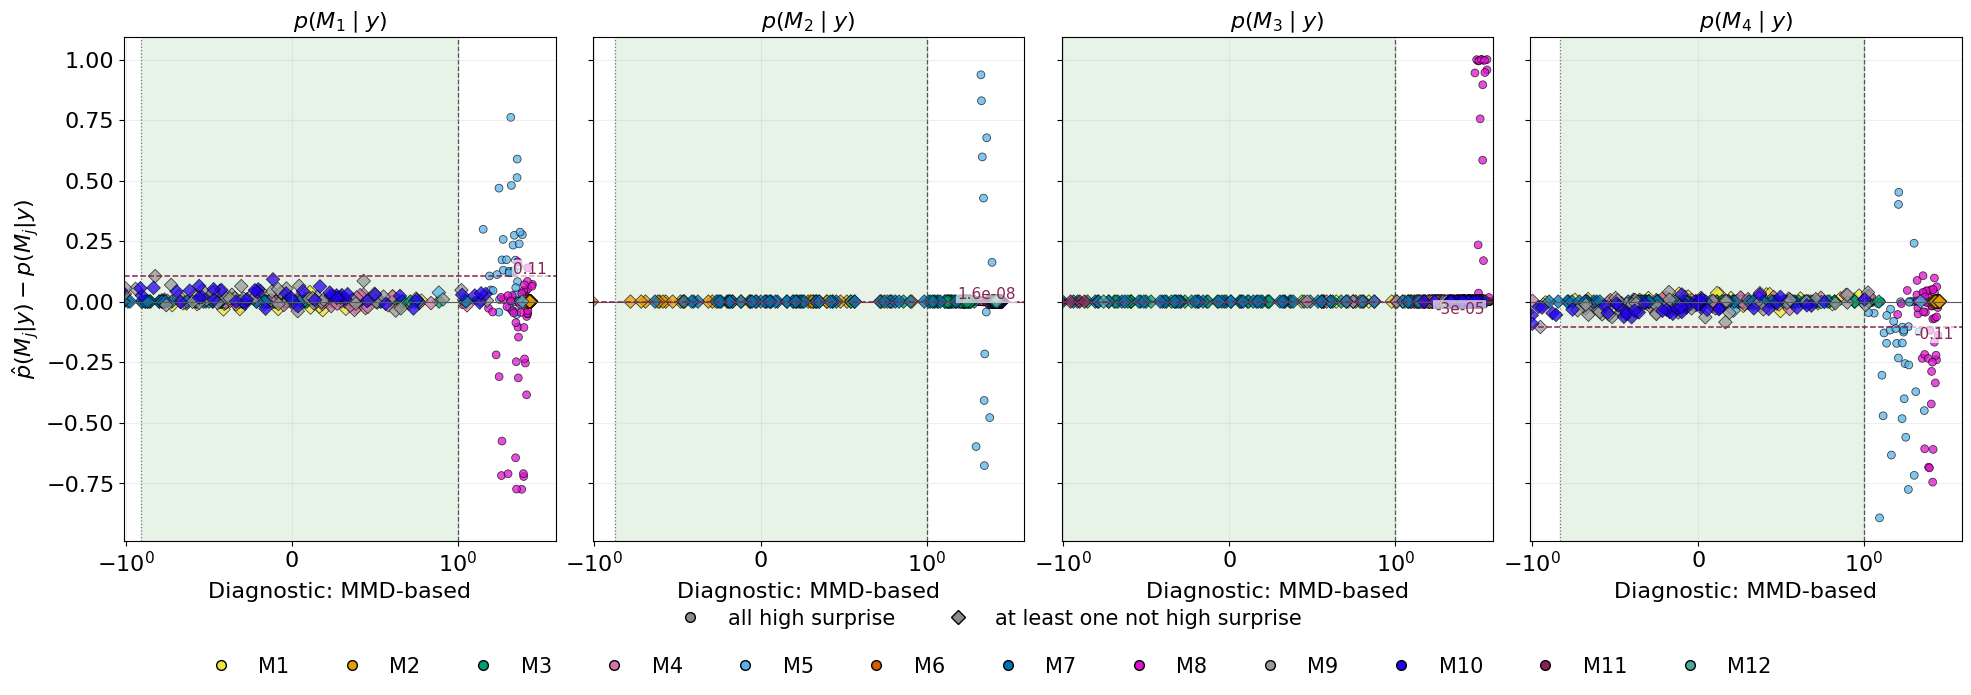

In [12]:
sd.plot_pmp_diagnostic(
    pmp_df,
    x="rho",
    y="signed_error",
    group_by="global_extrapolation_source",
    estimate="direct",
    output_dir=FIGURE_DIR,
    filename="pmp_error_direct_vs_rho.png",
    regions="assumed",
    sharex=True,
    x_min=-1.0,
    distance_metric=METRIC,
    xscale="symlog",
    yscale=YSCALE["pmp"],
    y_linthresh=PMP_Y_LINTHRESH,
);
